In [2]:
import numpy as np
from scipy import stats
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer, KNNImputer
from statsmodels.tsa.seasonal import STL
from tools.preprocess_lib import * #library bang kris

import matplotlib.pyplot as plt
from matplotlib.ticker import (AutoMinorLocator, MultipleLocator)
from datetime import datetime
import pandas as pd
import time
import csv
import os
import seaborn as sns

In [3]:
PICKLEPATH = f'df_prepare.pkl'
df_alldata = pd.read_pickle(PICKLEPATH)

In [4]:
# DATA_PATH = './pickle/prepare/'
# ALL_DATA = 'df_merge_Seoul.pkl'

# df_alldata = pd.read_pickle(PICKLEPATH)

In [5]:
df_alldata.head()

,House overall,temperature,humidity,apparentTemperature,pressure,cloudCover,windBearing,precipIntensity,dewPoint,precipProbability
time,,,,,,,,,,
2016-01-01 05:00:00,0.932833,36.14,0.62,29.26,1016.91,0.75,282.0,0.0,24.4,0.0
2016-01-01 05:01:00,0.934333,36.14,0.62,29.26,1016.91,0.75,282.0,0.0,24.4,0.0
2016-01-01 05:02:00,0.931817,36.14,0.62,29.26,1016.91,0.75,282.0,0.0,24.4,0.0
2016-01-01 05:03:00,1.022050,36.14,0.62,29.26,1016.91,0.75,282.0,0.0,24.4,0.0
2016-01-01 05:04:00,1.139400,36.14,0.62,29.26,1016.91,0.75,282.0,0.0,24.4,0.0


In [6]:
colu =[]
for col in df_alldata.columns:
#     print(col)
    colu.append(col)

In [7]:
# for column in df_alldata:
#     inspectData(df_alldata[column])

<AxesSubplot: >

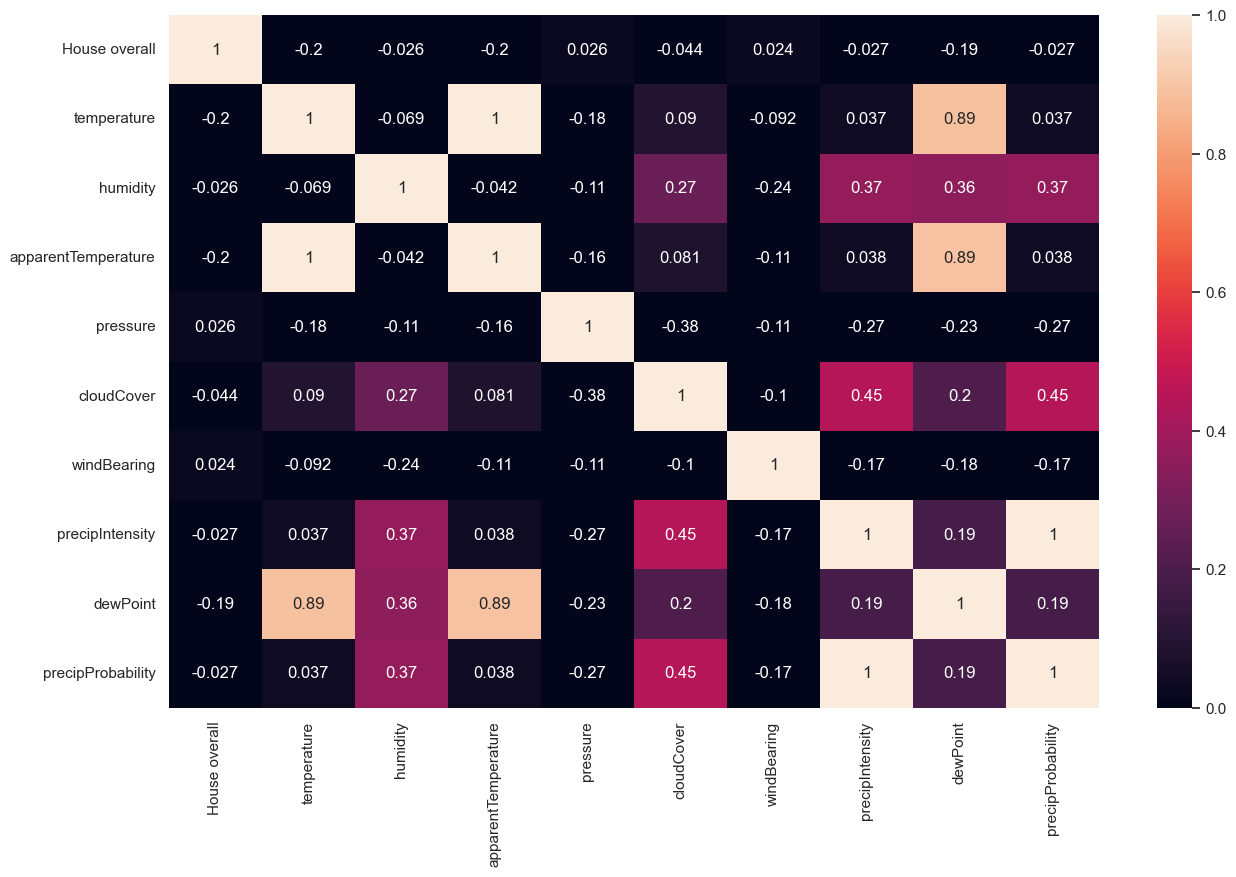

In [9]:
sns.set(rc={'figure.figsize':(15,9)})
sns.heatmap(df_alldata.corr(method='spearman'),vmin=0,vmax=1,annot=True)

In [28]:
# df_final = df_alldata[['House overall','ws','ss','ssQcflg','hm','P(kWh)']]
df_final = df_alldata

In [29]:
df_final.head()

,House overall,temperature,humidity,apparentTemperature,pressure,cloudCover,windBearing,precipIntensity,dewPoint,precipProbability
time,,,,,,,,,,
2016-01-01 05:00:00,0.932833,36.14,0.62,29.26,1016.91,0.75,282.0,0.0,24.4,0.0
2016-01-01 05:01:00,0.934333,36.14,0.62,29.26,1016.91,0.75,282.0,0.0,24.4,0.0
2016-01-01 05:02:00,0.931817,36.14,0.62,29.26,1016.91,0.75,282.0,0.0,24.4,0.0
2016-01-01 05:03:00,1.022050,36.14,0.62,29.26,1016.91,0.75,282.0,0.0,24.4,0.0
2016-01-01 05:04:00,1.139400,36.14,0.62,29.26,1016.91,0.75,282.0,0.0,24.4,0.0


<AxesSubplot: >

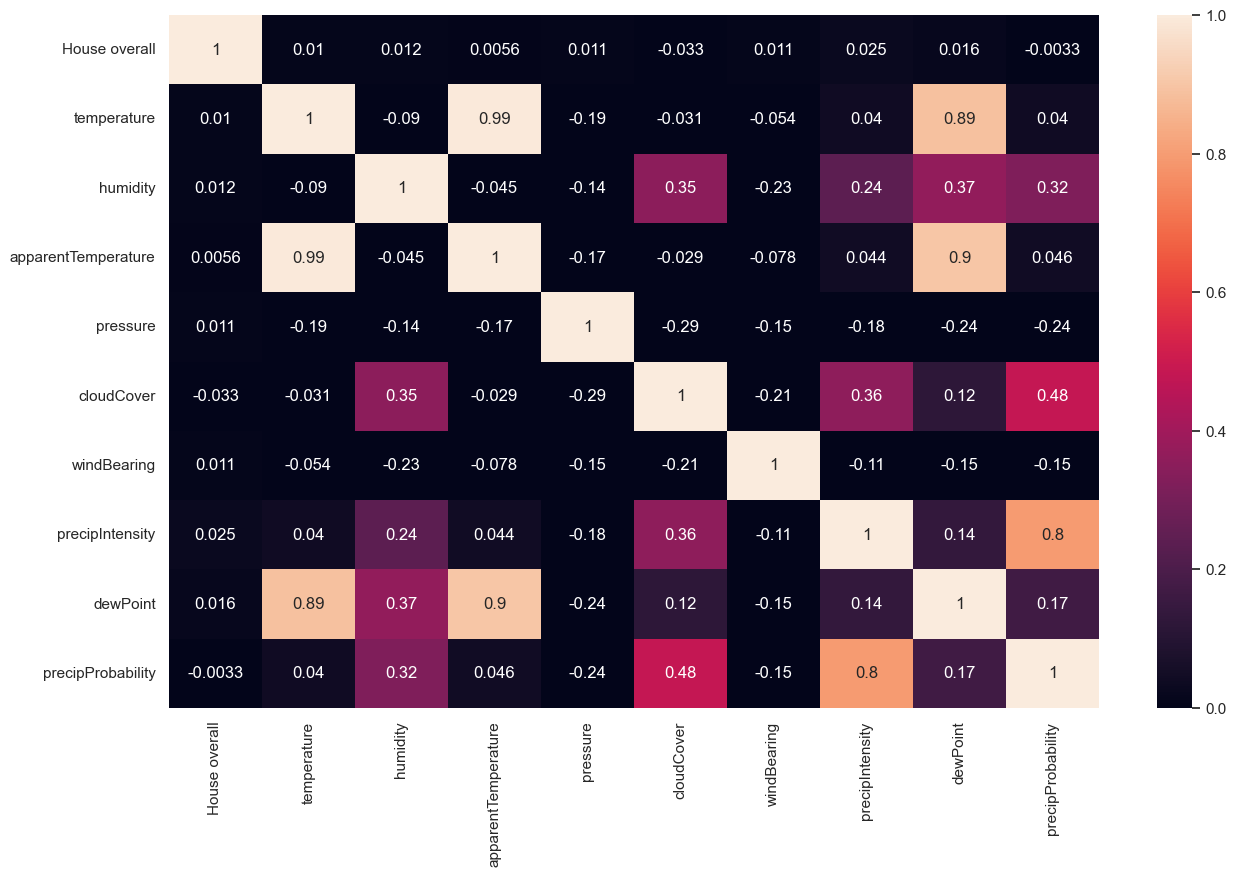

In [30]:
sns.set(rc={'figure.figsize':(15,9)})
sns.heatmap(df_final.corr(),vmin=0,vmax=1,annot=True)

In [15]:
# DATA_PATH = './pickle/ready/'
# DATA_NAME = 'df_final_Seoul.pkl'
# df_final.to_pickle(DATA_PATH + DATA_NAME)

In [31]:
MinMax = MinMaxScaler((-1,1))
np_alldata = MinMax.fit_transform(df_alldata)
df_alldata = pd.DataFrame(np_alldata, columns = colu)

In [32]:
df_alldata.describe()

,House overall,temperature,humidity,apparentTemperature,pressure,cloudCover,windBearing,precipIntensity,dewPoint,precipProbability
count,503910.000000,503910.000000,503910.000000,503910.000000,503910.000000,503910.000000,503910.000000,503910.000000,503910.000000,503910.000000
mean,-0.883250,0.191838,0.256671,0.206357,0.066772,-0.548109,0.127336,-0.972795,0.283637,-0.865588
std,0.143831,0.359417,0.457385,0.330749,0.281669,0.579889,0.593429,0.117872,0.371614,0.394848
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-0.950027,-0.089695,-0.105882,-0.051502,-0.112023,-0.920000,-0.175487,-1.000000,0.009248,-1.000000
50%,-0.923568,0.183904,0.294118,0.237237,0.074920,-0.760000,0.158774,-1.000000,0.290178,-1.000000
75%,-0.868124,0.483640,0.670588,0.476577,0.251516,-0.420000,0.643454,-1.000000,0.597002,-1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [34]:
PICKLEFINALPATH = f'df_final.pkl'

df_final.to_pickle(PICKLEFINALPATH)